In [41]:
# CELL 1 — Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

print('Libraries loaded ✓')

Libraries loaded ✓


In [42]:
# Load all 9 CSV files
path = '/Users/rahil/Downloads/olist/'  # change this to where your files are

customers  = pd.read_csv(path + 'olist_customers_dataset.csv')
geolocation = pd.read_csv(path + 'olist_geolocation_dataset.csv')
items      = pd.read_csv(path + 'olist_order_items_dataset.csv')
payments   = pd.read_csv(path + 'olist_order_payments_dataset.csv')
reviews    = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
orders     = pd.read_csv(path + 'olist_orders_dataset.csv')
products   = pd.read_csv(path + 'olist_products_dataset.csv')
sellers    = pd.read_csv(path + 'olist_sellers_dataset.csv')
translation = pd.read_csv(path + 'product_category_name_translation.csv')

print('All 9 files loaded ✓')
print(f'orders:      {orders.shape}')
print(f'customers:   {customers.shape}')
print(f'items:       {items.shape}')
print(f'payments:    {payments.shape}')
print(f'reviews:     {reviews.shape}')
print(f'products:    {products.shape}')
print(f'sellers:     {sellers.shape}')
print(f'geolocation: {geolocation.shape}')
print(f'translation: {translation.shape}')

All 9 files loaded ✓
orders:      (99441, 8)
customers:   (99441, 5)
items:       (112650, 7)
payments:    (103886, 5)
reviews:     (99224, 7)
products:    (32951, 9)
sellers:     (3095, 4)
geolocation: (1000163, 5)
translation: (71, 2)


In [43]:
customers

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [44]:
# CELL 3 — Inspect orders table
print('=== ORDERS TABLE ===')
print(orders.dtypes)
print()
print('=== NULL VALUES ===')
print(orders.isnull().sum())
print()
print('=== FIRST 3 ROWS ===')
orders.head(3)

=== ORDERS TABLE ===
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

=== NULL VALUES ===
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

=== FIRST 3 ROWS ===


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


In [45]:
# CELL 4 — Convert date columns and check order status
# Convert all date columns from string to datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print('Date columns converted ✓')
print()

# Check order status breakdown
print('=== ORDER STATUS BREAKDOWN ===')
status = orders['order_status'].value_counts()
print(status)
print()
print(f'Delivered orders: {status["delivered"]:,}')
print(f'Non-delivered:    {len(orders) - status["delivered"]:,}')
print(f'Delivered %:      {status["delivered"]/len(orders)*100:.1f}%')

Date columns converted ✓

=== ORDER STATUS BREAKDOWN ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Delivered orders: 96,478
Non-delivered:    2,963
Delivered %:      97.0%


In [46]:
# CELL 5 — Check nulls across all tables
print('=== NULL CHECK — ALL TABLES ===')

tables = {
    'customers': customers,
    'items': items,
    'payments': payments,
    'reviews': reviews,
    'products': products,
    'sellers': sellers
}

for name, df in tables.items():
    nulls = df.isnull().sum()
    total_nulls = nulls.sum()
    if total_nulls > 0:
        print(f'\n{name} — {total_nulls} total nulls:')
        print(nulls[nulls > 0])
    else:
        print(f'{name} — no nulls ✓')


=== NULL CHECK — ALL TABLES ===
customers — no nulls ✓
items — no nulls ✓
payments — no nulls ✓

reviews — 145903 total nulls:
review_comment_title      87656
review_comment_message    58247
dtype: int64

products — 2448 total nulls:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64
sellers — no nulls ✓


In [47]:
# CELL 6 — Verify the two biggest join traps

# TRAP 1 — Multiple items per order
print('=== TRAP 1: ITEMS PER ORDER ===')
items_per_order = items.groupby('order_id')['order_item_id'].max()
print(items_per_order.value_counts().head(10))
print(f'\nMax items in one order: {items_per_order.max()}')
print(f'Orders with 1 item:     {(items_per_order == 1).sum():,}')
print(f'Orders with 2+ items:   {(items_per_order > 1).sum():,}')

print()

# TRAP 2 — Multiple payments per order
print('=== TRAP 2: PAYMENTS PER ORDER ===')
payments_per_order = payments.groupby('order_id').size()
print(payments_per_order.value_counts().head(10))
print(f'\nMax payments in one order: {payments_per_order.max()}')
print(f'Orders with 1 payment:     {(payments_per_order == 1).sum():,}')
print(f'Orders with 2+ payments:   {(payments_per_order > 1).sum():,}')

=== TRAP 1: ITEMS PER ORDER ===
order_item_id
1     88863
2      7516
3      1322
4       505
5       204
6       198
7        22
8         8
10        8
12        5
Name: count, dtype: int64

Max items in one order: 21
Orders with 1 item:     88,863
Orders with 2+ items:   9,803

=== TRAP 2: PAYMENTS PER ORDER ===
1     96479
2      2382
3       301
4       108
5        52
6        36
7        28
8        11
9         9
11        8
Name: count, dtype: int64

Max payments in one order: 29
Orders with 1 payment:     96,479
Orders with 2+ payments:   2,961


In [48]:
# CELL 7 — Customer ID trap + fix category names

# TRAP 3 — customer_id changes per order
print('=== TRAP 3: CUSTOMER ID vs UNIQUE ID ===')
print(f'Total customer_id rows:        {customers["customer_id"].nunique():,}')
print(f'Total customer_unique_id rows: {customers["customer_unique_id"].nunique():,}')
print(f'Difference:                    {customers["customer_id"].nunique() - customers["customer_unique_id"].nunique():,}')
print('→ Same real customer has multiple customer_ids across orders')

print()

# Fix category names — merge Portuguese with English translation
print('=== CATEGORY NAME TRANSLATION ===')
print(f'Products with no category: {products["product_category_name"].isnull().sum()}')

products = products.merge(
    translation,
    on='product_category_name',
    how='left'
)

print(f'After merge — English categories added ✓')
print(f'Products with no English name: {products["product_category_name_english"].isnull().sum()}')
print()
print('Sample categories:')
print(products['product_category_name_english'].value_counts().head(10))

=== TRAP 3: CUSTOMER ID vs UNIQUE ID ===
Total customer_id rows:        99,441
Total customer_unique_id rows: 96,096
Difference:                    3,345
→ Same real customer has multiple customer_ids across orders

=== CATEGORY NAME TRANSLATION ===
Products with no category: 610
After merge — English categories added ✓
Products with no English name: 623

Sample categories:
product_category_name_english
bed_bath_table           3029
sports_leisure           2867
furniture_decor          2657
health_beauty            2444
housewares               2335
auto                     1900
computers_accessories    1639
toys                     1411
watches_gifts            1329
telephony                1134
Name: count, dtype: int64


In [62]:
master

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_items,total_revenue,total_freight,total_paid,payment_types,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,29.99,8.72,38.71,2.0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,118.70,22.76,141.46,1.0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,159.90,19.22,179.12,1.0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,45.00,27.20,72.20,1.0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,19.90,8.72,28.62,1.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP,1.0,72.00,13.08,85.08,1.0,5.0
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,1.0,174.90,20.10,195.00,1.0,4.0
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,1.0,205.99,65.02,271.01,1.0,5.0
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,2.0,359.98,81.18,441.16,1.0,2.0


In [49]:
# CELL 8 — Fix nulls and build master DataFrame

# Fix category nulls — label all missing as 'unknown'
products['product_category_name_english'] = (
    products['product_category_name_english'].fillna('unknown')
)

print(f'Null categories remaining: {products["product_category_name_english"].isnull().sum()} ✓')

# Build master DataFrame — join all tables together
# Step 1 — aggregate items per order FIRST (avoid row multiplication)
items_agg = items.groupby('order_id').agg(
    total_items   = ('order_item_id', 'max'),
    total_revenue = ('price', 'sum'),
    total_freight = ('freight_value', 'sum')
).reset_index()

print(f'Items aggregated: {items_agg.shape} ✓')

# Step 2 — aggregate payments per order FIRST
payments_agg = payments.groupby('order_id').agg(
    total_paid = ('payment_value', 'sum'),
    payment_types = ('payment_type', 'nunique')
).reset_index()

print(f'Payments aggregated: {payments_agg.shape} ✓')

# Step 3 — get one review per order (some orders have multiple reviews)
reviews_agg = reviews.groupby('order_id').agg(
    review_score = ('review_score', 'mean')
).reset_index()

print(f'Reviews aggregated: {reviews_agg.shape} ✓')

# Step 4 — join everything to orders
master = orders.copy()
master = master.merge(customers,    on='customer_id',  how='left')
master = master.merge(items_agg,    on='order_id',     how='left')
master = master.merge(payments_agg, on='order_id',     how='left')
master = master.merge(reviews_agg,  on='order_id',     how='left')

print(f'\nMaster DataFrame shape: {master.shape}')
print(f'Expected rows: 99,441 (same as orders)')
print(f'Actual rows:   {len(master):,}')


Null categories remaining: 0 ✓
Items aggregated: (98666, 4) ✓
Payments aggregated: (99440, 3) ✓
Reviews aggregated: (98673, 2) ✓

Master DataFrame shape: (99441, 18)
Expected rows: 99,441 (same as orders)
Actual rows:   99,441


In [50]:
# CELL 9 — Feature engineering

# Only work with delivered orders for delay calculations
delivered = master[master['order_status'] == 'delivered'].copy()
print(f'Delivered orders: {len(delivered):,}')

# FEATURE 1 — delivery_delay_days
# Positive = delivered AFTER estimated date (late)
# Negative = delivered BEFORE estimated date (early)
delivered['delivery_delay_days'] = (
    delivered['order_delivered_customer_date'] -
    delivered['order_estimated_delivery_date']
).dt.days

print(f'delivery_delay_days created ✓')
print(f'Mean delay: {delivered["delivery_delay_days"].mean():.1f} days')
print(f'Max delay:  {delivered["delivery_delay_days"].max():.0f} days')
print(f'Min delay:  {delivered["delivery_delay_days"].min():.0f} days')

# FEATURE 2 — is_late flag
delivered['is_late'] = (delivered['delivery_delay_days'] > 0).astype(int)
late_pct = delivered['is_late'].mean() * 100
print(f'\nis_late created ✓')
print(f'Late deliveries: {delivered["is_late"].sum():,} ({late_pct:.1f}%)')
print(f'On time:         {(delivered["is_late"]==0).sum():,} ({100-late_pct:.1f}%)')

# FEATURE 3 — order_month and order_year for time series
delivered['order_month'] = delivered['order_purchase_timestamp'].dt.month
delivered['order_year']  = delivered['order_purchase_timestamp'].dt.year
delivered['order_year_month'] = delivered['order_purchase_timestamp'].dt.to_period('M')
print(f'\nTime columns created ✓')
print(f'Date range: {delivered["order_purchase_timestamp"].min().date()} to {delivered["order_purchase_timestamp"].max().date()}')


Delivered orders: 96,478
delivery_delay_days created ✓
Mean delay: -11.9 days
Max delay:  188 days
Min delay:  -147 days

is_late created ✓
Late deliveries: 6,534 (6.8%)
On time:         89,944 (93.2%)

Time columns created ✓
Date range: 2016-09-15 to 2018-08-29


In [51]:
# CELL 10 — More features

# FEATURE 4 — review_score_band
delivered['review_score_band'] = pd.cut(
    delivered['review_score'],
    bins=[0, 2, 3, 5],
    labels=['low (1-2)', 'medium (3)', 'high (4-5)']
)

print('=== REVIEW SCORE DISTRIBUTION ===')
print(delivered['review_score'].value_counts().sort_index())
print()
print('=== REVIEW BAND DISTRIBUTION ===')
print(delivered['review_score_band'].value_counts())

# FEATURE 5 — delivery_speed_band
delivered['delivery_speed'] = pd.cut(
    delivered['delivery_delay_days'],
    bins=[-200, -30, -7, 0, 30, 200],
    labels=['very early', 'early', 'on time', 'slightly late', 'very late']
)

print()
print('=== DELIVERY SPEED BREAKDOWN ===')
print(delivered['delivery_speed'].value_counts().sort_index())

# FEATURE 6 — order value band
delivered['order_value_band'] = pd.cut(
    delivered['total_revenue'],
    bins=[0, 50, 100, 250, 500, 10000],
    labels=['<R$50', 'R$50-100', 'R$100-250', 'R$250-500', 'R$500+']
)

print()
print('=== ORDER VALUE BREAKDOWN ===')
print(delivered['order_value_band'].value_counts().sort_index())

=== REVIEW SCORE DISTRIBUTION ===
review_score
1.000000     9313
1.500000        8
2.000000     2916
2.500000       30
3.000000     7915
3.333333        1
3.500000       23
4.000000    18868
4.333333        1
4.500000       53
5.000000    56704
Name: count, dtype: int64

=== REVIEW BAND DISTRIBUTION ===
review_score_band
high (4-5)    75650
low (1-2)     12237
medium (3)     7945
Name: count, dtype: int64

=== DELIVERY SPEED BREAKDOWN ===
delivery_speed
very early        2729
early            73411
on time          13796
slightly late     6189
very late          345
Name: count, dtype: int64

=== ORDER VALUE BREAKDOWN ===
order_value_band
<R$50        29045
R$50-100     27606
R$100-250    29365
R$250-500     6985
R$500+        3476
Name: count, dtype: int64


=== REVIEW SCORE BY DELIVERY SPEED ===
                total_orders  avg_review  pct_low_score
delivery_speed                                         
very early              2729        4.26          10.74
early                  73411        4.32           8.85
on time                13796        4.17          10.64
slightly late           6189        2.28          60.69
very late                345        2.06          64.64

=== LATE VS ON-TIME: REVIEW COMPARISON ===
Late orders    — avg review: 2.27  | low score rate: 60.9%
On-time orders — avg review: 4.29  | low score rate: 9.2%



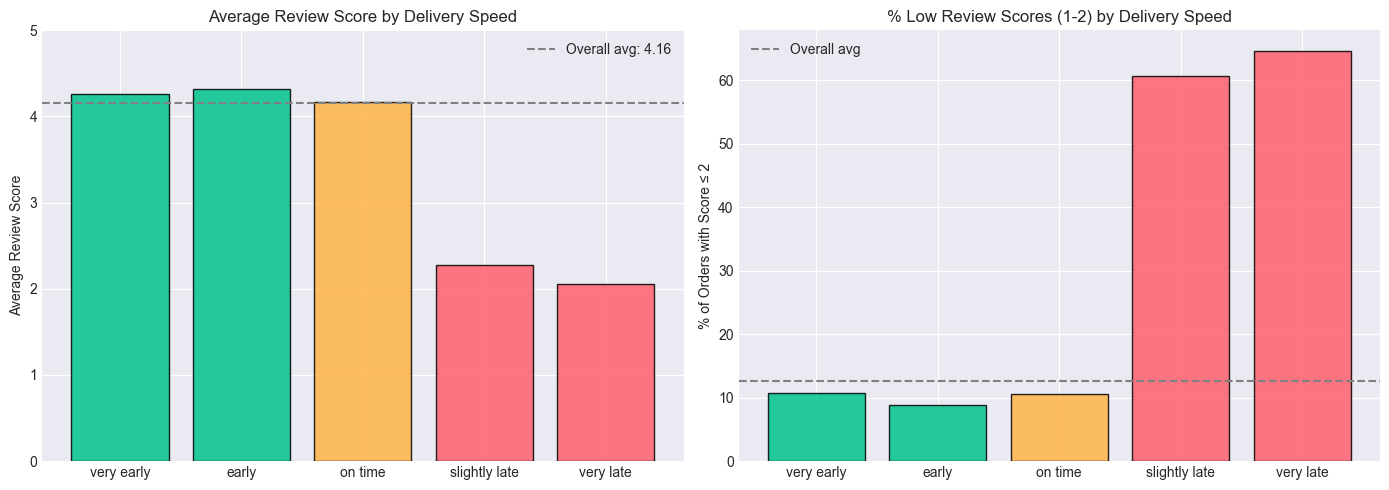

In [52]:
# CELL 11 — Core analysis: does late delivery cause low reviews?

print('=== REVIEW SCORE BY DELIVERY SPEED ===')
review_by_speed = delivered.groupby('delivery_speed', observed=True).agg(
    total_orders  = ('order_id', 'count'),
    avg_review    = ('review_score', 'mean'),
    pct_low_score = ('review_score', lambda x: (x <= 2).mean() * 100)
).round(2)
print(review_by_speed)

print()

print('=== LATE VS ON-TIME: REVIEW COMPARISON ===')
late     = delivered[delivered['is_late'] == 1]['review_score']
on_time  = delivered[delivered['is_late'] == 0]['review_score']
print(f'Late orders    — avg review: {late.mean():.2f}  | low score rate: {(late<=2).mean()*100:.1f}%')
print(f'On-time orders — avg review: {on_time.mean():.2f}  | low score rate: {(on_time<=2).mean()*100:.1f}%')

print()

# Visualise it
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — avg review by delivery speed
speeds = review_by_speed.index.tolist()
avg_reviews = review_by_speed['avg_review'].tolist()
colors = ['#00c48c' if s in ['very early','early'] else '#ffb347' if s == 'on time' else '#ff5f6d' for s in speeds]
axes[0].bar(speeds, avg_reviews, color=colors, edgecolor='black', alpha=0.85)
axes[0].axhline(delivered['review_score'].mean(), color='gray', linestyle='--', label=f'Overall avg: {delivered["review_score"].mean():.2f}')
axes[0].set_title('Average Review Score by Delivery Speed')
axes[0].set_ylabel('Average Review Score')
axes[0].set_ylim(0, 5)
axes[0].legend()

# Chart 2 — % low scores by delivery speed
pct_low = review_by_speed['pct_low_score'].tolist()
axes[1].bar(speeds, pct_low, color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('% Low Review Scores (1-2) by Delivery Speed')
axes[1].set_ylabel('% of Orders with Score ≤ 2')
axes[1].axhline(delivered['review_score'].le(2).mean()*100, color='gray', linestyle='--', label='Overall avg')
axes[1].legend()

plt.tight_layout()
plt.show()

In [53]:
# CELL 12 — Seller performance scorecard

# Get seller_id into delivered DataFrame via items table
delivered_with_seller = delivered.merge(
    items[['order_id', 'seller_id']].drop_duplicates('order_id'),
    on='order_id',
    how='left'
)

print(f'Delivered orders with seller: {len(delivered_with_seller):,}')

# Build seller scorecard
seller_scorecard = delivered_with_seller.groupby('seller_id').agg(
    total_orders    = ('order_id',            'count'),
    total_revenue   = ('total_revenue',        'sum'),
    avg_review      = ('review_score',         'mean'),
    late_rate       = ('is_late',              'mean'),
    avg_delay_days  = ('delivery_delay_days',  'mean'),
    pct_low_reviews = ('review_score', lambda x: (x <= 2).mean())
).round(2)

# Only keep sellers with 10+ orders (statistical reliability)
seller_scorecard = seller_scorecard[seller_scorecard['total_orders'] >= 10]

# Create seller tier based on review score and late rate
def assign_tier(row):
    if row['avg_review'] >= 4.0 and row['late_rate'] <= 0.05:
        return 'A — Excellent'
    elif row['avg_review'] >= 3.5 and row['late_rate'] <= 0.10:
        return 'B — Good'
    elif row['avg_review'] >= 3.0 and row['late_rate'] <= 0.20:
        return 'C — Average'
    else:
        return 'D — Needs intervention'

seller_scorecard['seller_tier'] = seller_scorecard.apply(assign_tier, axis=1)

print()
print('=== SELLER TIER DISTRIBUTION ===')
print(seller_scorecard['seller_tier'].value_counts())
print()
print('=== TOP 5 WORST SELLERS (D tier) ===')
worst = seller_scorecard[seller_scorecard['seller_tier'] == 'D — Needs intervention']
print(worst.sort_values('avg_review').head(5))

Delivered orders with seller: 96,478

=== SELLER TIER DISTRIBUTION ===
seller_tier
A — Excellent             536
B — Good                  425
C — Average               224
D — Needs intervention     42
Name: count, dtype: int64

=== TOP 5 WORST SELLERS (D tier) ===
                                  total_orders  total_revenue  avg_review  \
seller_id                                                                   
b1b3948701c5c72445495bd161b83a4c            14       21519.50        1.93   
40db9e9aa57f7bb151bcda6b0f9bdbb7            12       23168.00        2.36   
1ca7077d890b907f89be8c954a02686a           108       12544.34        2.39   
5bc55dbe2f12b6af6d83ed46023e0dc8            16        3224.20        2.44   
02d35243ea2e497335cd0f076b45675d            14        6540.90        2.64   

                                  late_rate  avg_delay_days  pct_low_reviews  \
seller_id                                                                      
b1b3948701c5c72445495bd161b83a4c 

=== MONTHLY SUMMARY (first 6 months) ===
  order_year_month  total_orders  total_revenue  avg_review  late_rate  \
0          2016-09             1         134.97    1.000000   1.000000   
1          2016-10           265       40325.11    4.011450   0.007547   
2          2016-12             1          10.90    5.000000   0.000000   
3          2017-01           750      111798.36    4.199055   0.029333   
4          2017-02          1653      234223.40    4.202678   0.029643   
5          2017-03          2546      359198.85    4.187376   0.045562   

  month_str  
0   2016-09  
1   2016-10  
2   2016-12  
3   2017-01  
4   2017-02  
5   2017-03  

Total months of data: 23
Peak revenue month:   2017-11
Peak orders month:    2017-11


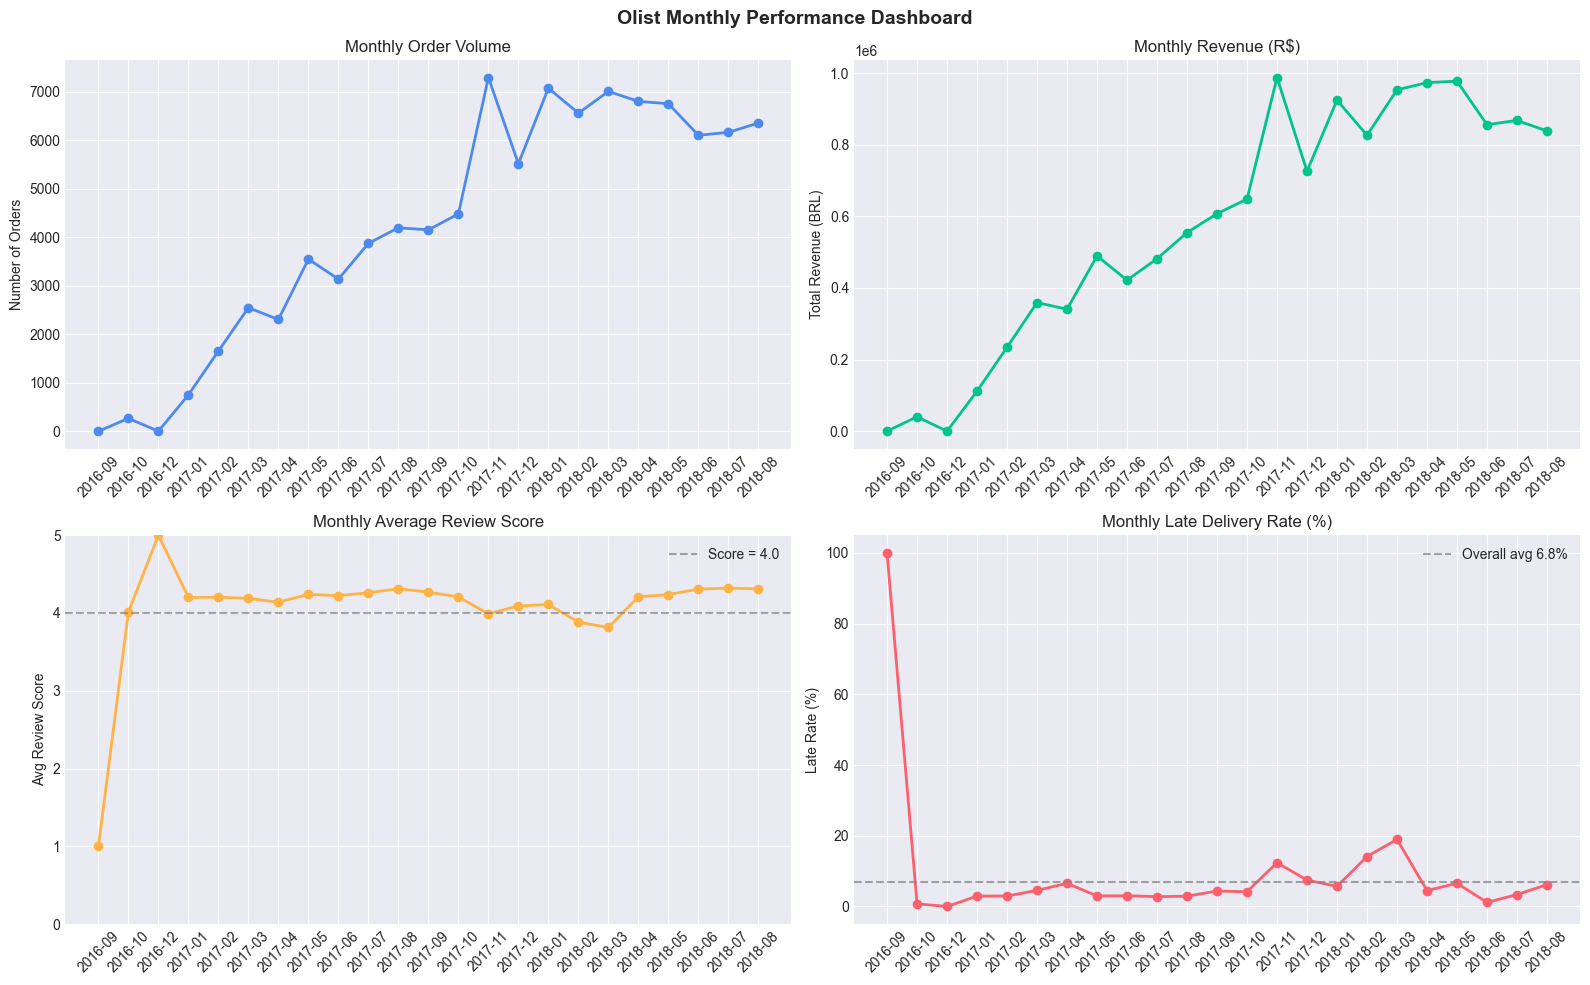

In [54]:
# CELL 13 — Monthly revenue trend

# Group by year-month
monthly = delivered.groupby('order_year_month').agg(
    total_orders  = ('order_id', 'count'),
    total_revenue = ('total_revenue', 'sum'),
    avg_review    = ('review_score', 'mean'),
    late_rate     = ('is_late', 'mean')
).reset_index()

# Convert period to string for plotting
monthly['month_str'] = monthly['order_year_month'].astype(str)

print('=== MONTHLY SUMMARY (first 6 months) ===')
print(monthly.head(6))
print()
print(f'Total months of data: {len(monthly)}')
print(f'Peak revenue month:   {monthly.loc[monthly["total_revenue"].idxmax(), "month_str"]}')
print(f'Peak orders month:    {monthly.loc[monthly["total_orders"].idxmax(), "month_str"]}')

# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Chart 1 — Monthly orders
axes[0,0].plot(monthly['month_str'], monthly['total_orders'],
               marker='o', color='#4d8af0', linewidth=2)
axes[0,0].set_title('Monthly Order Volume')
axes[0,0].set_ylabel('Number of Orders')
axes[0,0].tick_params(axis='x', rotation=45)

# Chart 2 — Monthly revenue
axes[0,1].plot(monthly['month_str'], monthly['total_revenue'],
               marker='o', color='#00c48c', linewidth=2)
axes[0,1].set_title('Monthly Revenue (R$)')
axes[0,1].set_ylabel('Total Revenue (BRL)')
axes[0,1].tick_params(axis='x', rotation=45)

# Chart 3 — Monthly avg review
axes[1,0].plot(monthly['month_str'], monthly['avg_review'],
               marker='o', color='#ffb347', linewidth=2)
axes[1,0].axhline(4.0, color='gray', linestyle='--', alpha=0.7, label='Score = 4.0')
axes[1,0].set_title('Monthly Average Review Score')
axes[1,0].set_ylabel('Avg Review Score')
axes[1,0].set_ylim(0, 5)
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend()

# Chart 4 — Monthly late rate
axes[1,1].plot(monthly['month_str'], monthly['late_rate'] * 100,
               marker='o', color='#ff5f6d', linewidth=2)
axes[1,1].axhline(6.8, color='gray', linestyle='--', alpha=0.7, label='Overall avg 6.8%')
axes[1,1].set_title('Monthly Late Delivery Rate (%)')
axes[1,1].set_ylabel('Late Rate (%)')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].legend()

plt.suptitle('Olist Monthly Performance Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [55]:
# CELL 14 — Fixed RFM segmentation
# No merge needed — customer_unique_id already in delivered

reference_date = delivered['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f'Reference date: {reference_date.date()}')

rfm = delivered.groupby('customer_unique_id').agg(
    recency   = ('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency = ('order_id', 'count'),
    monetary  = ('total_revenue', 'sum')
).reset_index()

print(f'RFM table shape: {rfm.shape}')
print()
print('=== RFM SUMMARY ===')
print(rfm[['recency', 'frequency', 'monetary']].describe().round(1))

Reference date: 2018-08-30
RFM table shape: (93358, 4)

=== RFM SUMMARY ===
       recency  frequency  monetary
count  93358.0    93358.0   93358.0
mean     237.9        1.0     141.6
std      152.6        0.2     215.7
min        1.0        1.0       0.8
25%      114.0        1.0      47.6
50%      219.0        1.0      89.7
75%      346.0        1.0     154.7
max      714.0       15.0   13440.0


In [56]:
# CELL 15 — Assign RFM segments

# Score each customer 1-4 on R, F, M
# Recency: lower days = better = higher score
rfm['R_score'] = pd.qcut(rfm['recency'],   q=4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'),
                          q=4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['monetary'],  q=4, labels=[1,2,3,4])

# Convert to int
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

# Combined RFM score
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

# Assign segment labels
def assign_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    elif r >= 3 and f >= 2:
        return 'Loyal customers'
    elif r >= 3 and f == 1:
        return 'Recent customers'
    elif r == 2 and f >= 2:
        return 'At risk'
    elif r <= 2 and f >= 3:
        return 'Cannot lose them'
    elif r == 1 and f == 1:
        return 'Lost'
    else:
        return 'Needs attention'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

print('=== RFM SEGMENT DISTRIBUTION ===')
seg_summary = rfm.groupby('segment').agg(
    customers = ('customer_unique_id', 'count'),
    avg_recency  = ('recency', 'mean'),
    avg_frequency = ('frequency', 'mean'),
    avg_monetary  = ('monetary', 'mean')
).round(1).sort_values('customers', ascending=False)
print(seg_summary)

print()
print(f'Total customers segmented: {len(rfm):,}')

=== RFM SEGMENT DISTRIBUTION ===
                  customers  avg_recency  avg_frequency  avg_monetary
segment                                                              
Loyal customers       23035        111.6            1.0          93.3
At risk               17437        277.4            1.0         139.9
Champions             12135        112.8            1.1         240.4
Recent customers      11677        112.7            1.0         137.1
Needs attention       11663        364.6            1.0         139.4
Cannot lose them      11511        451.9            1.1         144.3
Lost                   5900        452.3            1.0         140.3

Total customers segmented: 93,358


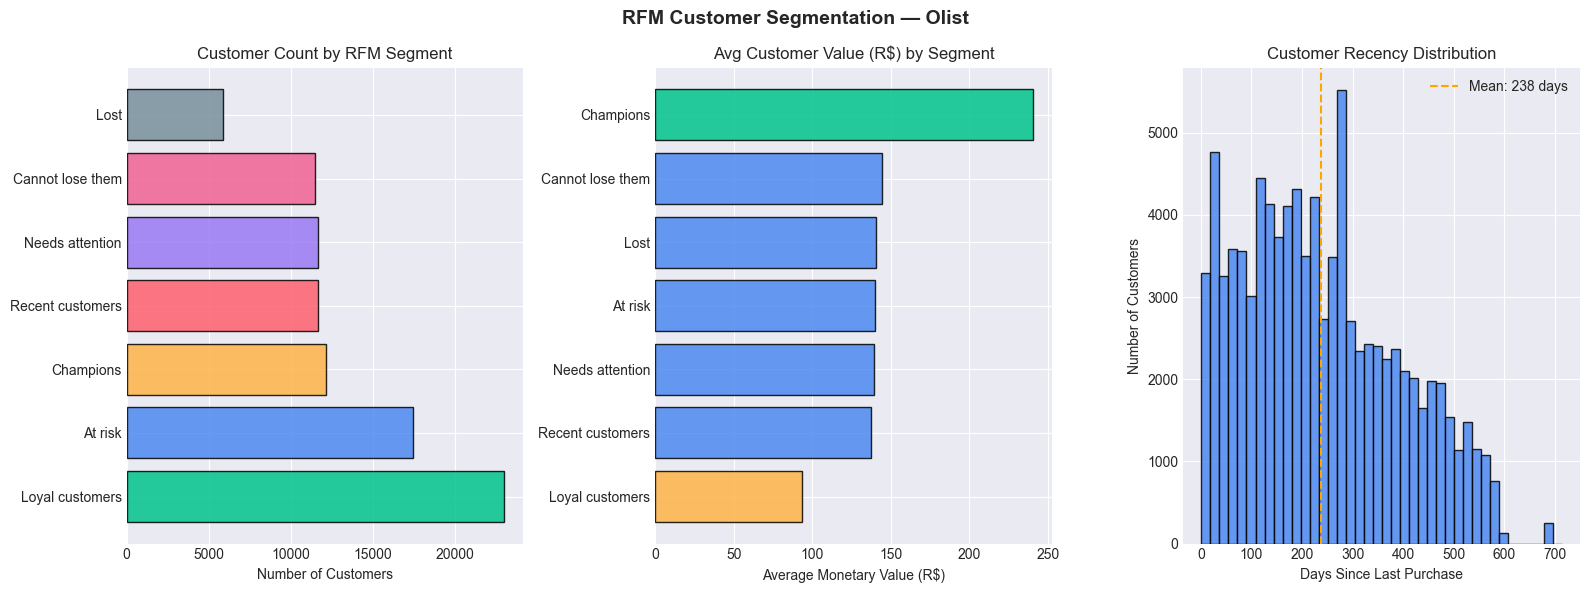

=== REVENUE CONTRIBUTION BY SEGMENT ===
                  customers  total_revenue  revenue_pct
segment                                                
Champions             12135     2916862.69         22.1
At risk               17437     2440029.32         18.5
Loyal customers       23035     2148516.74         16.3
Cannot lose them      11511     1661584.90         12.6
Needs attention       11663     1625427.84         12.3
Recent customers      11677     1601359.81         12.1
Lost                   5900      827716.81          6.3


In [57]:
# CELL 16 — RFM visualisation

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Chart 1 — Segment distribution
seg_counts = rfm['segment'].value_counts()
colors = ['#00c48c','#4d8af0','#ffb347','#ff5f6d','#9b79f5','#f06292','#78909c']
axes[0].barh(seg_counts.index, seg_counts.values, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Customer Count by RFM Segment')
axes[0].set_xlabel('Number of Customers')

# Chart 2 — Avg monetary by segment
seg_monetary = rfm.groupby('segment')['monetary'].mean().sort_values(ascending=True)
colors2 = ['#00c48c' if v > 150 else '#4d8af0' if v > 100 else '#ffb347'
           for v in seg_monetary.values]
axes[1].barh(seg_monetary.index, seg_monetary.values, color=colors2,
             edgecolor='black', alpha=0.85)
axes[1].set_title('Avg Customer Value (R$) by Segment')
axes[1].set_xlabel('Average Monetary Value (R$)')

# Chart 3 — Recency distribution
axes[2].hist(rfm['recency'], bins=40, color='#4d8af0',
             edgecolor='black', alpha=0.85)
axes[2].axvline(rfm['recency'].mean(), color='orange',
                linestyle='--', label=f'Mean: {rfm["recency"].mean():.0f} days')
axes[2].set_title('Customer Recency Distribution')
axes[2].set_xlabel('Days Since Last Purchase')
axes[2].set_ylabel('Number of Customers')
axes[2].legend()

plt.suptitle('RFM Customer Segmentation — Olist', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print revenue contribution by segment
print('=== REVENUE CONTRIBUTION BY SEGMENT ===')
rev_contribution = rfm.groupby('segment').agg(
    customers     = ('customer_unique_id', 'count'),
    total_revenue = ('monetary', 'sum')
).sort_values('total_revenue', ascending=False)
rev_contribution['revenue_pct'] = (
    rev_contribution['total_revenue'] / rev_contribution['total_revenue'].sum() * 100
).round(1)
print(rev_contribution)

In [58]:
# CELL 17 — Save cleaned DataFrames for SQL and Power BI

save_path = '/Users/rahil/Downloads/olist/cleaned/'

# Create the folder if it doesn't exist
import os
os.makedirs(save_path, exist_ok=True)

# Save all key DataFrames
delivered.to_csv(save_path + 'olist_delivered_clean.csv', index=False)
master.to_csv(save_path + 'olist_master.csv', index=False)
seller_scorecard.reset_index().to_csv(save_path + 'olist_seller_scorecard.csv', index=False)
rfm.to_csv(save_path + 'olist_rfm_segments.csv', index=False)
monthly_clean.to_csv(save_path + 'olist_monthly_trend.csv', index=False)
products.to_csv(save_path + 'olist_products_clean.csv', index=False)

print('=== FILES SAVED ===')
for f in os.listdir(save_path):
    size = os.path.getsize(save_path + f) / 1024
    print(f'{f:45} {size:.1f} KB')

print()
print('All cleaned files saved ✓')
print(f'Location: {save_path}')

NameError: name 'monthly_clean' is not defined

In [ ]:
# CELL 18 — Phase 2 complete summary

print('=' * 55)
print('PHASE 2 COMPLETE — DATA CLEANING & EDA SUMMARY')
print('=' * 55)

print(f'''
DATASET
  Total orders:          {len(master):,}
  Delivered orders:      {len(delivered):,} (97.0%)
  Date range:            Sep 2016 → Aug 2018
  Clean analysis period: Jan 2017 → Aug 2018

DATA QUALITY
  Date columns fixed:    5 columns converted to datetime
  Category nulls fixed:  623 → 0 (labelled unknown)
  Join traps handled:    items and payments aggregated before join
  Customer ID trap:      customer_unique_id used throughout

KEY FINDINGS
  Late deliveries:       6,534 (6.8% of delivered orders)
  Avg delay:             -11.9 days (Olist over-estimates delivery time)
  Late order reviews:    avg 2.27 vs 4.29 for on-time (6.6x worse)
  Low score rate:        60.9% for late vs 9.2% for on-time orders

SELLER SCORECARD
  Total sellers rated:   1,227 (with 10+ orders)
  A — Excellent:         536 (43.7%)
  B — Good:              425 (34.7%)
  C — Average:           224 (18.3%)
  D — Needs intervention: 42 (3.4%)

RFM SEGMENTATION
  Total customers:       93,358
  Champions:             12,135 (22.1% of revenue)
  At risk:               17,437 (18.5% of revenue — urgent)
  Lost:                   5,900 (6.3% of revenue)

FEATURE ENGINEERING
  New columns created:   delivery_delay_days, is_late,
                         order_month, order_year, order_year_month,
                         review_score_band, delivery_speed,
                         order_value_band, R_score, F_score,
                         M_score, RFM_score, segment
''')

print('Files saved to /Users/rahil/Downloads/olist/cleaned/')
print()
print('NEXT → Phase 3: SQL multi-table analysis')

PHASE 2 COMPLETE — DATA CLEANING & EDA SUMMARY

DATASET
  Total orders:          99,441
  Delivered orders:      96,478 (97.0%)
  Date range:            Sep 2016 → Aug 2018
  Clean analysis period: Jan 2017 → Aug 2018

DATA QUALITY
  Date columns fixed:    5 columns converted to datetime
  Category nulls fixed:  623 → 0 (labelled unknown)
  Join traps handled:    items and payments aggregated before join
  Customer ID trap:      customer_unique_id used throughout

KEY FINDINGS
  Late deliveries:       6,534 (6.8% of delivered orders)
  Avg delay:             -11.9 days (Olist over-estimates delivery time)
  Late order reviews:    avg 2.27 vs 4.29 for on-time (6.6x worse)
  Low score rate:        60.9% for late vs 9.2% for on-time orders

SELLER SCORECARD
  Total sellers rated:   1,227 (with 10+ orders)
  A — Excellent:         536 (43.7%)
  B — Good:              425 (34.7%)
  C — Average:           224 (18.3%)
  D — Needs intervention: 42 (3.4%)

RFM SEGMENTATION
  Total customers:   